# PCSE Yield Prediction — LightGBM Regresyon

**Hedef:** `twso_final` (kg/ha eşdeğeri tane verimi)  
**Veri:** `ml_dataset_multiyear.parquet` (pipeline01 çıktısı)  
**İçerik:**
1. Veri yükle & keşif
2. DVS < 1.0 filtresi + Feature seçimi
3. Split bazlı train/val/test ayrımı
4. GroupKFold validasyon (sadece train içinde)
5. Hyperparameter tuning (Optuna)
6. Final model eğitimi
7. Feature importance
8. SHAP analizi
9. Hata analizi
10. Crop bazlı breakdown
11. Model kaydetme

In [1]:
# !pip install lightgbm optuna shap matplotlib seaborn -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import optuna
import shap
import joblib
import warnings
from pathlib import Path
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

DATA_FILE = 'ml_dataset_multiyear.parquet'  # GÜNCELLENDI
BASE_DIR = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / 'data' / DATA_FILE).exists():
        BASE_DIR = candidate
        break
if BASE_DIR is None:
    BASE_DIR = Path('/Users/sanlilarburak/Documents/Projects/pcse-ml')

DATA_DIR     = BASE_DIR / 'data'
MODEL_DIR    = BASE_DIR / 'models'
MODEL_DIR.mkdir(exist_ok=True)

COMBO        = ['district_name', 'crop_name', 'variety_name', 'year']  # GÜNCELLENDI
TARGET       = 'twso_final'
RANDOM_STATE = 42

print('Kütüphaneler yüklendi.')
print(f'BASE_DIR : {BASE_DIR}')
print(f'DATA_DIR : {DATA_DIR}')
print(f'LightGBM : {lgb.__version__}')
print(f'Optuna   : {optuna.__version__}')

/Users/sanlilarburak/Documents/Projects/pcse-ml/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Kütüphaneler yüklendi.
BASE_DIR : /Users/sanlilarburak/Documents/Projects/pcse-ml
DATA_DIR : /Users/sanlilarburak/Documents/Projects/pcse-ml/data
LightGBM : 4.6.0
Optuna   : 4.8.0


---
## 1. Veri Yükle & Keşif

In [3]:
from pyarrow import parquet as pq  # GÜNCELLENDI

parquet_path = DATA_DIR / 'ml_dataset_multiyear.parquet'  # GÜNCELLENDI
try:
    df_raw = pd.read_parquet(parquet_path, engine='pyarrow')  # GÜNCELLENDI
except OSError as exc:
    print(f'pd.read_parquet hata verdi, pyarrow direct read deneniyor: {exc}')  # GÜNCELLENDI
    df_raw = pq.read_table(parquet_path).to_pandas()  # GÜNCELLENDI

if 'split' not in df_raw.columns:  # GÜNCELLENDI
    if 'year' in df_raw.columns:  # GÜNCELLENDI
        split_map = {2014: 'train', 2015: 'train', 2016: 'train', 2017: 'train', 2018: 'train', 2019: 'train', 2020: 'train', 2021: 'train', 2022: 'val', 2023: 'val', 2024: 'test'}  # GÜNCELLENDI
        df_raw['split'] = df_raw['year'].map(split_map).fillna('holdout')  # GÜNCELLENDI
        print("'split' kolonu parquet içinde yoktu; year'dan türetildi.")  # GÜNCELLENDI
    else:
        raise KeyError("'split' kolonu bulunamadı ve year kolonu da yok; veri seti uyumsuz.")  # GÜNCELLENDI

print(f'Ham veri  — Satır: {len(df_raw):,}  |  Sütun: {df_raw.shape[1]}')
print(f'Kombinasyon: {df_raw.groupby(COMBO).ngroups}')
print(f'Tarih: {df_raw["date"].min().date()} → {df_raw["date"].max().date()}')
print(f'Split dağılımı: {df_raw["split"].value_counts().to_dict()}')
df_raw.head(3)

'split' kolonu parquet içinde yoktu; year'dan türetildi.
Ham veri  — Satır: 715,186  |  Sütun: 54
Kombinasyon: 2755
Tarih: 2014-01-01 → 2024-12-01
Split dağılımı: {'train': 522223, 'val': 128488, 'test': 64475}


,date,district_name,crop_name,variety_name,year,season_id,AIR_TEMP_mean,AIR_TEMP_min,AIR_TEMP_max,AIR_HUMIDITY_mean,...,longitude,soil_type,crop_name_enc,variety_name_enc,district_name_enc,soil_type_enc,growth_stage_enc,data_split,cv_group,split
0,2014-01-01,"Adana, Karataş",barley,Spring_barley_301,2014,"Adana, Karataş_barley_Spring_barley_301_2014",11.672917,8.825,14.875,80.576226,...,35.375,Very Fine Heavy Clay,0,13,0,11,2,train,"Adana, Karataş_barley",train
1,2014-01-01,"Adana, Karataş",cassava,Cassava_VanHeemst_1988,2014,"Adana, Karataş_cassava_Cassava_VanHeemst_1988_...",11.672917,8.825,14.875,80.576226,...,35.375,Very Fine Heavy Clay,1,0,0,11,2,train,"Adana, Karataş_cassava",train
2,2014-01-01,"Adana, Karataş",chickpea,Chickpea_VanHeemst_1988,2014,"Adana, Karataş_chickpea_Chickpea_VanHeemst_198...",11.672917,8.825,14.875,80.576226,...,35.375,Very Fine Heavy Clay,2,1,0,11,2,train,"Adana, Karataş_chickpea",train


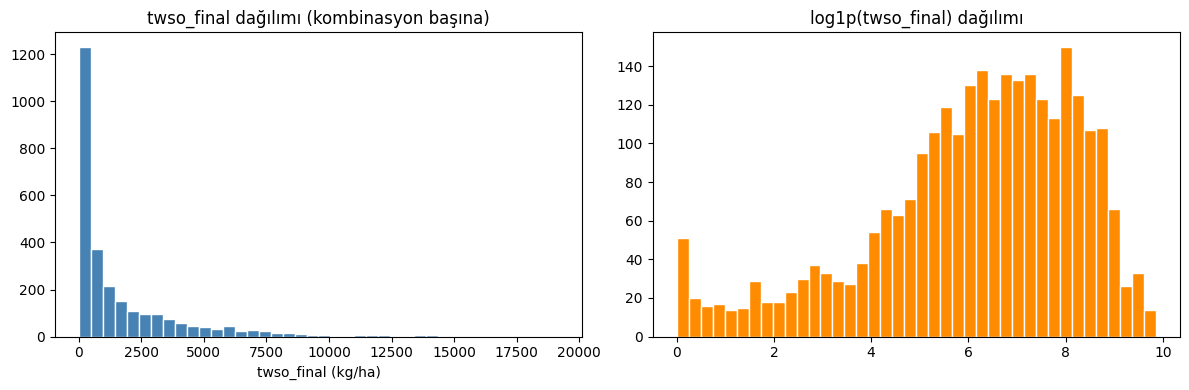

count     2755.0
mean      1781.7
std       2684.3
min          0.0
25%        144.3
50%        623.2
75%       2311.4
max      19161.0
Name: twso_final, dtype: float64


In [4]:
combo_verim = df_raw.groupby(COMBO)[TARGET].first()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(combo_verim, bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('twso_final dağılımı (kombinasyon başına)')
axes[0].set_xlabel('twso_final (kg/ha)')
axes[1].hist(np.log1p(combo_verim), bins=40, color='darkorange', edgecolor='white')
axes[1].set_title('log1p(twso_final) dağılımı')
plt.tight_layout()
plt.show()
print(combo_verim.describe().round(1))

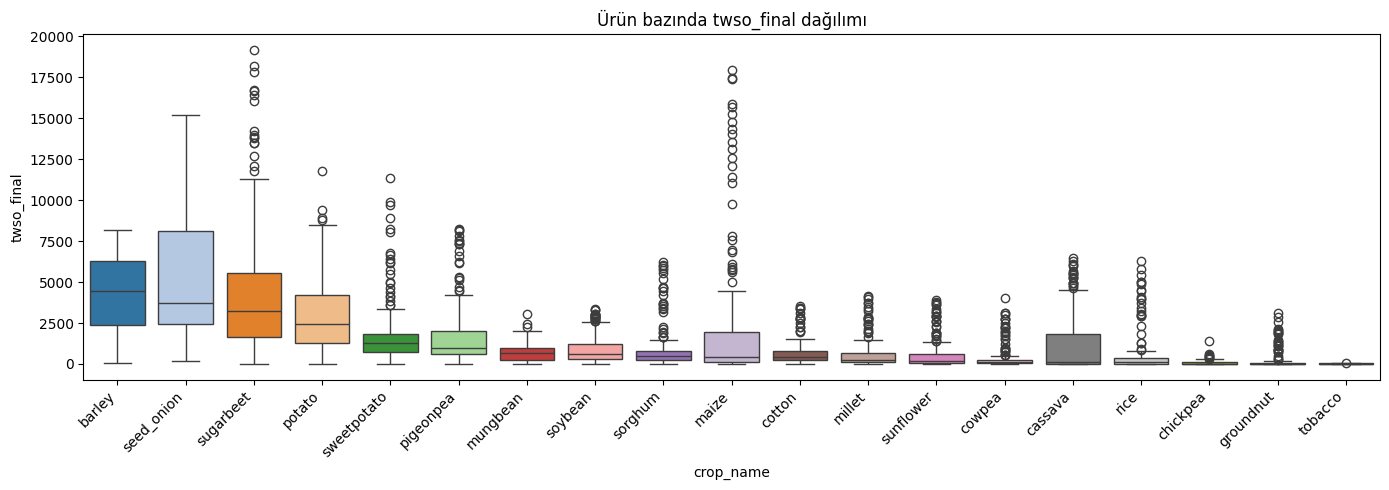

In [5]:
plt.figure(figsize=(14, 5))
order = combo_verim.reset_index().groupby('crop_name')[TARGET].median().sort_values(ascending=False).index
sns.boxplot(data=combo_verim.reset_index(), x='crop_name', y=TARGET, order=order, palette='tab20')
plt.xticks(rotation=45, ha='right')
plt.title('Ürün bazında twso_final dağılımı')
plt.tight_layout()
plt.show()

---
## 2. DVS < 1.0 Filtresi + Feature Seçimi

**Neden DVS < 1.0?**  
DVS ≥ 1.0 döneminde biyokütle değişkenleri hasat verimiyle neredeyse doğrusal ilişkiye girer → sızıntı.  
Model vejetatif dönemde (erken sezonda) tahmin yapabilmeli — bu daha gerçekçi ve pratik.

**Çıkarılan sızdırıcı sütunlar:**  
`TWSO`, `TAGP`, `TWLV`, `TWST`, `TWRT` — hasat sonuna yaklaştıkça target ile yüksek korelasyon.

In [6]:
df = df_raw[df_raw['DVS'] < 1.0].copy().reset_index(drop=True)

train_df = df[df['split'] == 'train'].copy().reset_index(drop=True)  # GÜNCELLENDI
val_df   = df[df['split'] == 'val'].copy().reset_index(drop=True)    # GÜNCELLENDI
test_df  = df[df['split'] == 'test'].copy().reset_index(drop=True)   # GÜNCELLENDI

print(f'DVS < 1.0 sonrası — Satır: {len(df):,}  ({len(df)/len(df_raw)*100:.1f}%)')
print(f'Train : {len(train_df):,}  |  Val : {len(val_df):,}  |  Test : {len(test_df):,}')
print(f'Kombinasyon (train): {train_df.groupby(COMBO).ngroups}')
print(f'DVS aralığı: {df["DVS"].min():.3f} → {df["DVS"].max():.3f}')

DVS < 1.0 sonrası — Satır: 185,673  (26.0%)
Train : 135,457  |  Val : 34,403  |  Test : 15,813
Kombinasyon (train): 2010
DVS aralığı: -0.100 → 1.000


In [7]:
LEAKY_COLS = ['TWSO', 'TAGP', 'TWLV', 'TWST', 'TWRT']
ROLLING_COLS = [c for c in df.columns if c.startswith('roll')]  # pipeline01'de üretilen rolling feature'lar — sızıntı riski

DROP_COLS = [
    'date', 'district_name', 'crop_name', 'variety_name',
    'soil_type', 'growth_stage',
    'year', 'season_id', 'split', 'data_split', 'cv_group',  # GÜNCELLENDI
    'tbase',
    TARGET,
    *LEAKY_COLS,
    *ROLLING_COLS  # roll7_*, roll30_* sütunları çıkar
]

FEATURE_COLS = [c for c in df.columns if c not in DROP_COLS]
print(f'Feature sayısı: {len(FEATURE_COLS)}')
print(FEATURE_COLS)

Feature sayısı: 36
['AIR_TEMP_mean', 'AIR_TEMP_min', 'AIR_TEMP_max', 'AIR_HUMIDITY_mean', 'AIR_HUMIDITY_min', 'AIR_HUMIDITY_max', 'PRECIP_sum', 'SOIL_TEMP_0_7_mean', 'SOIL_MOISTURE_0_7_mean', 'DVS', 'LAI', 'TRA', 'RD', 'SM', 'WWLOW', 'RFTRA', 'GDD_daily', 'GDD_cumsum', 'PRECIP_cumsum', 'AIR_TEMP_mean_roll7', 'AIR_TEMP_mean_roll30', 'AIR_HUMIDITY_mean_roll7', 'AIR_HUMIDITY_mean_roll30', 'SOIL_MOISTURE_0_7_mean_roll7', 'SOIL_MOISTURE_0_7_mean_roll30', 'TEMP_range', 'day_of_year', 'month', 'week', 'latitude', 'longitude', 'crop_name_enc', 'variety_name_enc', 'district_name_enc', 'soil_type_enc', 'growth_stage_enc']


In [8]:
X_train = train_df[FEATURE_COLS].copy()
y_train = train_df[TARGET].copy()
X_val   = val_df[FEATURE_COLS].copy()
y_val   = val_df[TARGET].copy()
X_test  = test_df[FEATURE_COLS].copy()
y_test  = test_df[TARGET].copy()

# GroupKFold yalnızca train_df içinde
train_groups = train_df['district_name'].astype(str) + '_' + train_df['crop_name'].astype(str)  # GÜNCELLENDI
missing = X_train.isna().sum()
if missing.any():
    print('Eksik değer olan sütunlar:')
    print(missing[missing > 0])
    X_train = X_train.fillna(X_train.median())
    X_val   = X_val.fillna(X_train.median())
    X_test  = X_test.fillna(X_train.median())
    print('Medyan ile dolduruldu.')
else:
    print('Eksik değer yok ✓')

print(f'\nX_train shape : {X_train.shape}')
print(f'X_val shape   : {X_val.shape}')
print(f'X_test shape  : {X_test.shape}')
print(f'y_train stats : mean={y_train.mean():.1f}  std={y_train.std():.1f}  min={y_train.min():.1f}  max={y_train.max():.1f}')

Eksik değer yok ✓

X_train shape : (135457, 36)
X_val shape   : (34403, 36)
X_test shape  : (15813, 36)
y_train stats : mean=1813.0  std=2707.8  min=0.0  max=19161.0


---
## 3. GroupKFold Validasyon

Her fold'da farklı `district × crop × variety` kombinasyonları test setine girer.  
Model hiç görmediği kombinasyonlarda genelleme gücü ölçülür.

In [9]:
N_SPLITS = 5
gkf      = GroupKFold(n_splits=N_SPLITS)
FINAL_CV = list(gkf.split(X_train, y_train, train_groups))  # GÜNCELLENDI

print(f'GroupKFold ({N_SPLITS} fold) — yalnızca train_df üzerinde:')
for i, (tr, val) in enumerate(FINAL_CV):
    print(f'  Fold {i+1}: train={len(tr):>6,} satır ({train_groups.iloc[tr].nunique()} kombo)  |  '
          f'val={len(val):>5,} satır ({train_groups.iloc[val].nunique()} kombo)')
print(f'\nHoldout test seti: {len(X_test):,} satır  |  Val seti: {len(X_val):,} satır')

GroupKFold (5 fold) — yalnızca train_df üzerinde:
  Fold 1: train=108,331 satır (217 kombo)  |  val=27,126 satır (55 kombo)
  Fold 2: train=108,359 satır (218 kombo)  |  val=27,098 satır (54 kombo)
  Fold 3: train=108,374 satır (218 kombo)  |  val=27,083 satır (54 kombo)
  Fold 4: train=108,432 satır (218 kombo)  |  val=27,025 satır (54 kombo)
  Fold 5: train=108,332 satır (217 kombo)  |  val=27,125 satır (55 kombo)

Holdout test seti: 15,813 satır  |  Val seti: 34,403 satır


In [10]:
# Baseline CV (tuning öncesi)
BASE_PARAMS = {
    'objective': 'regression', 'metric': 'rmse',
    'n_estimators': 500, 'learning_rate': 0.05, 'num_leaves': 63,
    'min_child_samples': 20, 'subsample': 0.8, 'colsample_bytree': 0.8,
    'random_state': RANDOM_STATE, 'n_jobs': -1, 'verbose': -1,
}

rmse_cv, r2_cv = [], []
for tr, val in FINAL_CV:
    m = lgb.LGBMRegressor(**BASE_PARAMS)
    m.fit(
        X_train.iloc[tr], y_train.iloc[tr],
        eval_set=[(X_train.iloc[val], y_train.iloc[val])],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)]
    )
    p = m.predict(X_train.iloc[val])
    rmse_cv.append(mean_squared_error(y_train.iloc[val], p) ** 0.5)
    r2_cv.append(r2_score(y_train.iloc[val], p))

print(f'Baseline GroupKFold CV (train_df, DVS<1, sızıntı yok):')
print(f'  RMSE : {np.mean(rmse_cv):.1f} ± {np.std(rmse_cv):.1f}')
print(f'  R²   : {np.mean(r2_cv):.4f}')
print(f'Val seti sanity: {len(X_val):,} satır')

Baseline GroupKFold CV (train_df, DVS<1, sızıntı yok):
  RMSE : 1431.1 ± 359.5
  R²   : 0.7079
Val seti sanity: 34,403 satır


---
## 4. Hyperparameter Tuning (Optuna)

In [11]:
def objective(trial):
    params = {
        'objective': 'regression', 'metric': 'rmse',
        'verbosity': -1, 'n_jobs': -1, 'random_state': RANDOM_STATE,
        'n_estimators':      1000,
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'num_leaves':        trial.suggest_int('num_leaves', 31, 255),
        'max_depth':         trial.suggest_int('max_depth', 4, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'min_split_gain':    trial.suggest_float('min_split_gain', 0.0, 1.0),
    }
    rmse_list = []
    for tr, val in FINAL_CV:
        m = lgb.LGBMRegressor(**params)
        m.fit(
            X_train.iloc[tr], y_train.iloc[tr],
            eval_set=[(X_train.iloc[val], y_train.iloc[val])],
            callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)]
        )
        p = m.predict(X_train.iloc[val])
        rmse_list.append(mean_squared_error(y_train.iloc[val], p) ** 0.5)
    return np.mean(rmse_list)

study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)
study.optimize(objective, n_trials=80, show_progress_bar=True)

print(f'\nBaseline CV RMSE : {np.mean(rmse_cv):.2f}')
print(f'Optuna CV RMSE   : {study.best_value:.2f}')
print(f'İyileşme         : {np.mean(rmse_cv) - study.best_value:.2f}')
print('\nEn iyi params:')
for k, v in study.best_params.items():
    print(f'  {k}: {v}')

Best trial: 45. Best value: 1348.61: 100%|██████████| 80/80 [35:02<00:00, 26.28s/it] 


Baseline CV RMSE : 1431.14
Optuna CV RMSE   : 1348.61
İyileşme         : 82.53

En iyi params:
  learning_rate: 0.08973245011159507
  num_leaves: 33
  max_depth: 8
  min_child_samples: 38
  subsample: 0.792825917264304
  colsample_bytree: 0.8037807983951626
  reg_alpha: 0.25439006905174266
  reg_lambda: 0.006205311940864061
  min_split_gain: 0.09493663721704484


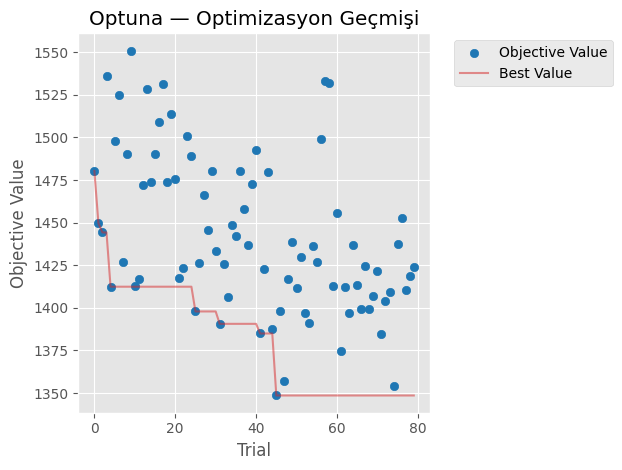

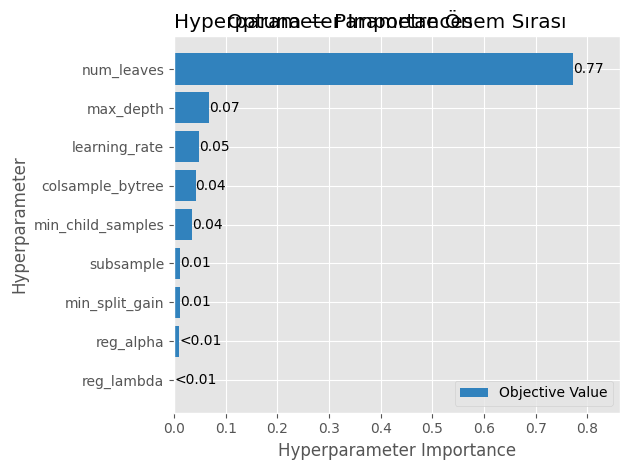

In [12]:
fig = optuna.visualization.matplotlib.plot_optimization_history(study)
plt.title('Optuna — Optimizasyon Geçmişi')
plt.tight_layout()
plt.show()

fig2 = optuna.visualization.matplotlib.plot_param_importances(study)
plt.title('Optuna — Parametre Önem Sırası')
plt.tight_layout()
plt.show()

---
## 5. Final Model Eğitimi

In [13]:
def safe_mape(y_true, y_pred, threshold=100):
    mask = np.asarray(y_true) > threshold
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((np.asarray(y_true)[mask] - np.asarray(y_pred)[mask]) / np.asarray(y_true)[mask])) * 100

BEST_PARAMS = {
    'objective': 'regression', 'metric': 'rmse',
    'n_estimators': 2000, 'n_jobs': -1, 'random_state': RANDOM_STATE,
    **study.best_params
}

final_model = lgb.LGBMRegressor(**BEST_PARAMS)
final_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],  # GÜNCELLENDI
    callbacks=[lgb.early_stopping(100, verbose=True), lgb.log_evaluation(100)]
)

y_pred = final_model.predict(X_test)

rmse = mean_squared_error(y_test, y_pred) ** 0.5
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)
mape      = np.mean(np.abs((y_test - y_pred) / (y_test + 1e-6))) * 100
safe_mape_val = safe_mape(y_test.values, y_pred, threshold=100)

print('\n── Final Model Test Metrikleri (train/val/test split, DVS<1) ──')
print(f'RMSE : {rmse:>8.2f}')
print(f'MAE  : {mae:>8.2f}')
print(f'R²   : {r2:>8.4f}')
print(f'MAPE      : {mape:>7.2f}%')
print(f'safe_MAPE : {safe_mape_val:>7.2f}%  (twso>100 filtreli)')

Training until validation scores don't improve for 100 rounds
[100]	valid_0's rmse: 1089.83
[200]	valid_0's rmse: 1060.04
[300]	valid_0's rmse: 1052.85
Early stopping, best iteration is:
[274]	valid_0's rmse: 1051.68

── Final Model Test Metrikleri (train/val/test split, DVS<1) ──
RMSE :  1007.28
MAE  :   592.19
R²   :   0.8356
MAPE      : 27108.46%
safe_MAPE :   61.21%  (twso>100 filtreli)


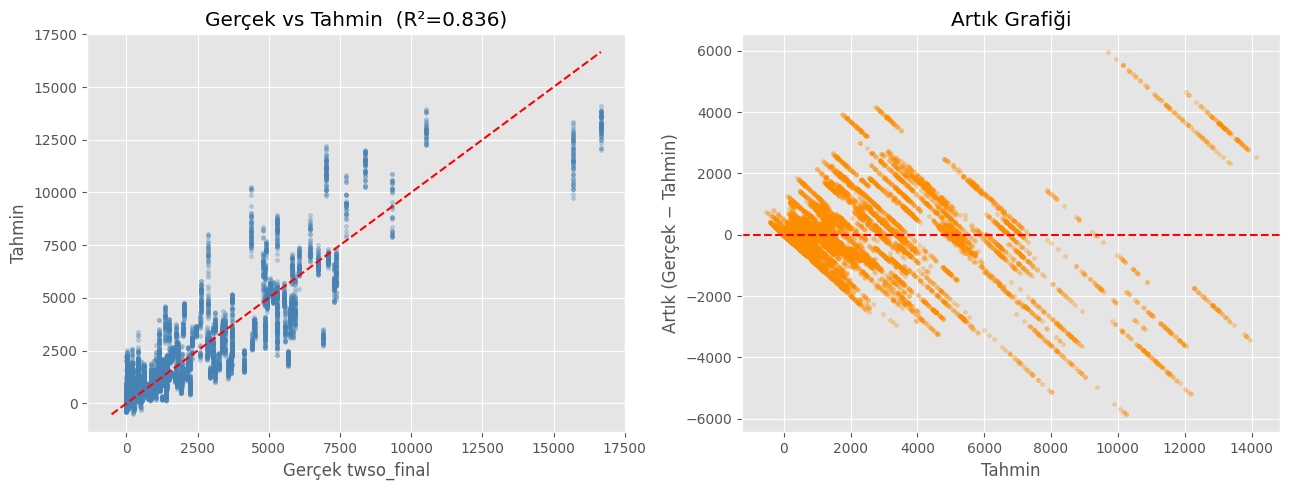

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, y_pred, alpha=0.3, s=8, color='steelblue')
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--', lw=1.5)
axes[0].set_xlabel('Gerçek twso_final')
axes[0].set_ylabel('Tahmin')
axes[0].set_title(f'Gerçek vs Tahmin  (R²={r2:.3f})')

residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.3, s=8, color='darkorange')
axes[1].axhline(0, color='r', lw=1.5, ls='--')
axes[1].set_xlabel('Tahmin')
axes[1].set_ylabel('Artık (Gerçek − Tahmin)')
axes[1].set_title('Artık Grafiği')

plt.tight_layout()
plt.show()

---
## 6. Feature Importance

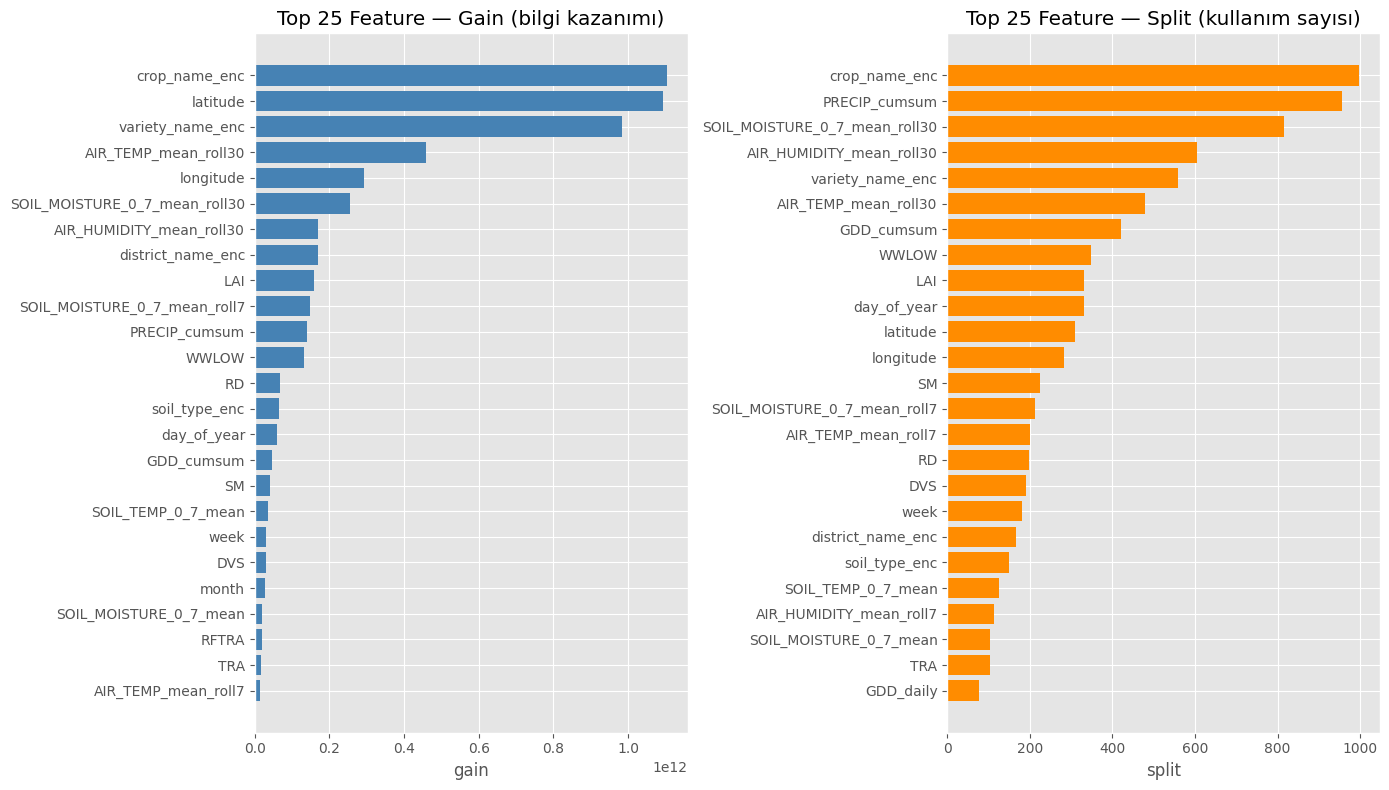

Top 15 feature (gain):
                      feature         gain  split
                crop_name_enc 1.104276e+12    998
                     latitude 1.093801e+12    310
             variety_name_enc 9.838588e+11    559
         AIR_TEMP_mean_roll30 4.580998e+11    479
                    longitude 2.918607e+11    282
SOIL_MOISTURE_0_7_mean_roll30 2.549770e+11    816
     AIR_HUMIDITY_mean_roll30 1.697728e+11    605
            district_name_enc 1.695662e+11    166
                          LAI 1.580200e+11    331
 SOIL_MOISTURE_0_7_mean_roll7 1.481216e+11    213
                PRECIP_cumsum 1.403291e+11    956
                        WWLOW 1.320247e+11    348
                           RD 6.627582e+10    198
                soil_type_enc 6.560542e+10    150
                  day_of_year 5.825582e+10    331


In [15]:
imp_df = pd.DataFrame({
    'feature': FEATURE_COLS,
    'gain':    final_model.booster_.feature_importance(importance_type='gain'),
    'split':   final_model.booster_.feature_importance(importance_type='split'),
}).sort_values('gain', ascending=False)

top_n = 25
fig, axes = plt.subplots(1, 2, figsize=(14, 8))
for ax, col, color, title in [
    (axes[0], 'gain',  'steelblue', 'Gain (bilgi kazanımı)'),
    (axes[1], 'split', 'darkorange', 'Split (kullanım sayısı)'),
]:
    sub = imp_df.nlargest(top_n, col)
    ax.barh(sub['feature'][::-1], sub[col][::-1], color=color)
    ax.set_title(f'Top {top_n} Feature — {title}')
    ax.set_xlabel(col)
plt.tight_layout()
plt.show()

print('Top 15 feature (gain):')
print(imp_df.head(15)[['feature','gain','split']].to_string(index=False))

---
## 7. SHAP Analizi

In [16]:
sample_idx  = np.random.choice(len(X_test), min(2000, len(X_test)), replace=False)
X_shap      = X_test.iloc[sample_idx]
explainer   = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_shap)
print('SHAP değerleri hesaplandı.')

SHAP değerleri hesaplandı.


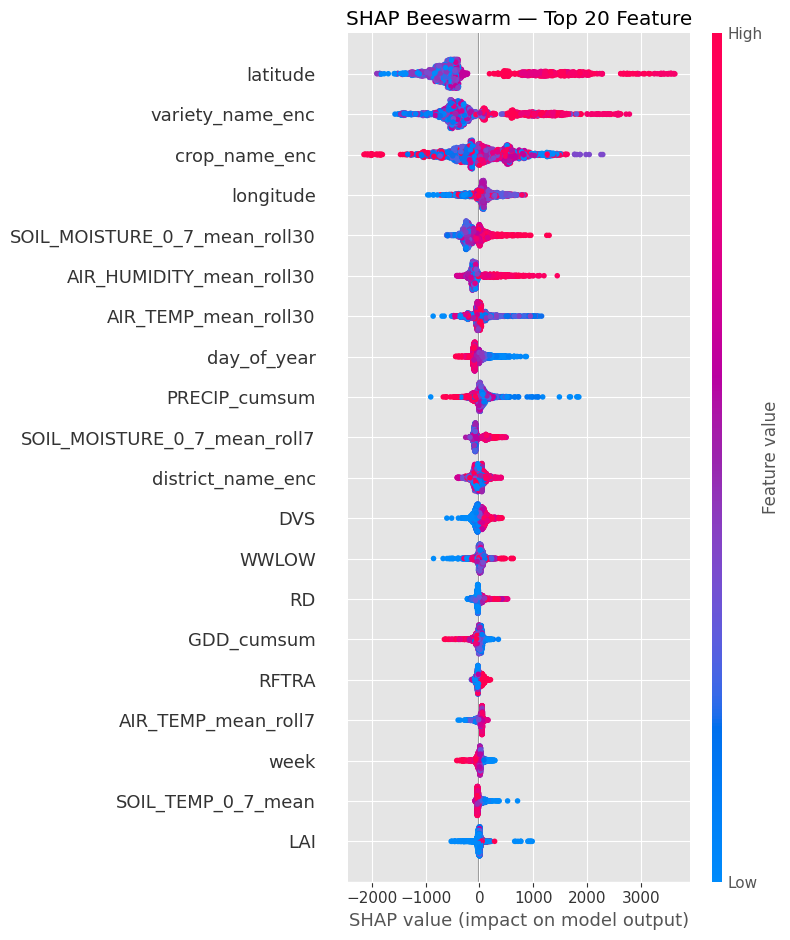

In [17]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_shap, max_display=20, show=False)
plt.title('SHAP Beeswarm — Top 20 Feature')
plt.tight_layout()
plt.show()

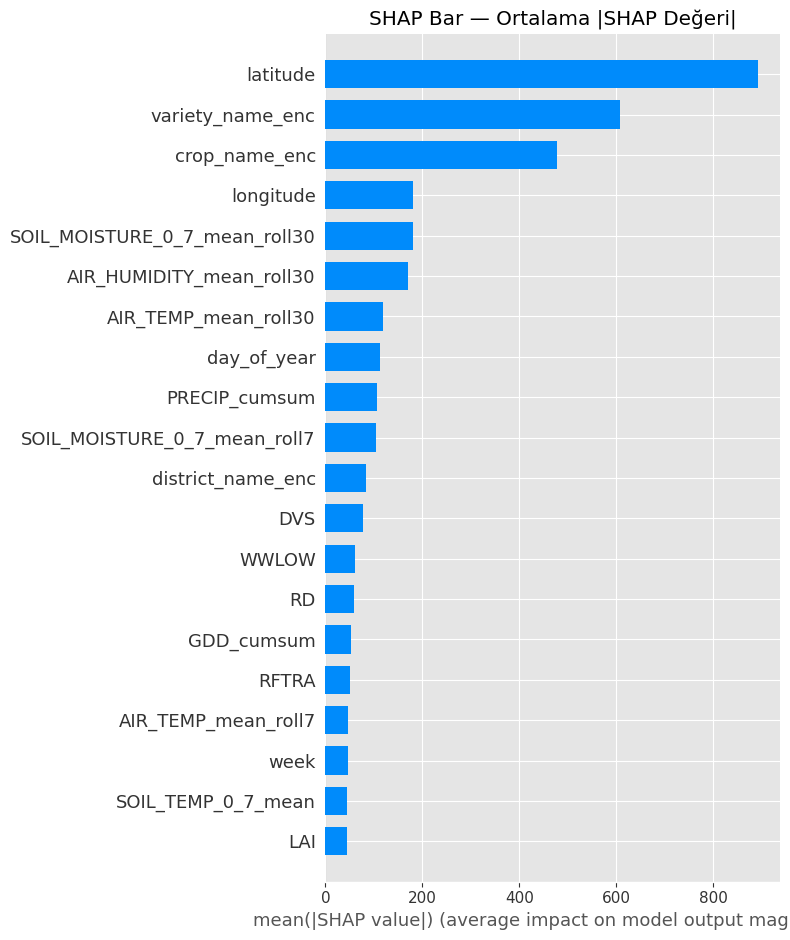

In [18]:
plt.figure(figsize=(9, 7))
shap.summary_plot(shap_values, X_shap, plot_type='bar', max_display=20, show=False)
plt.title('SHAP Bar — Ortalama |SHAP Değeri|')
plt.tight_layout()
plt.show()

<Figure size 800x400 with 0 Axes>

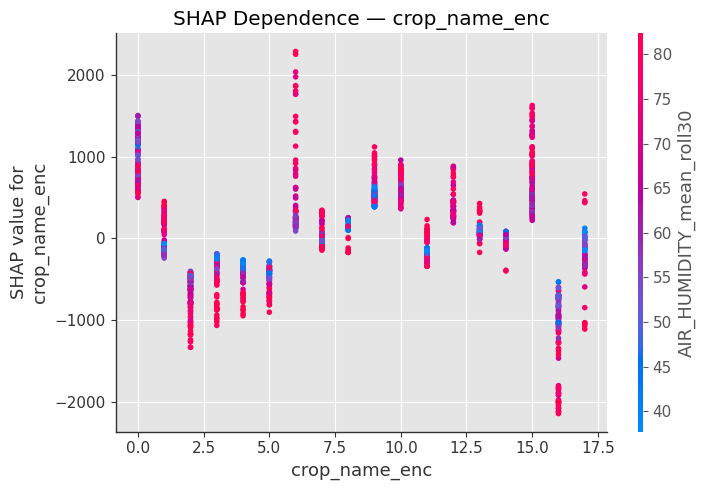

<Figure size 800x400 with 0 Axes>

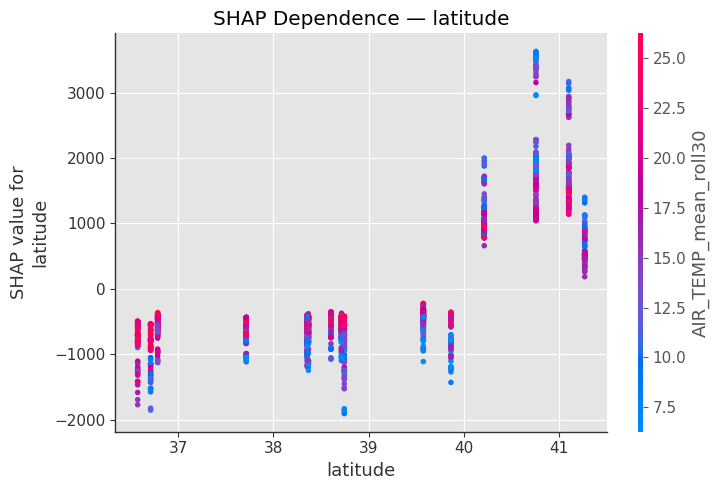

In [19]:
top2 = imp_df['feature'].head(2).tolist()
for feat in top2:
    plt.figure(figsize=(8, 4))
    shap.dependence_plot(feat, shap_values, X_shap, show=False)
    plt.title(f'SHAP Dependence — {feat}')
    plt.tight_layout()
    plt.show()

---
## 8. Hata Analizi

In [20]:
test_df = test_df.copy()  # GÜNCELLENDI
test_df['y_pred']    = y_pred
test_df['residual']  = y_test.values - y_pred
test_df['abs_error'] = np.abs(test_df['residual'])
test_df['rel_error'] = test_df['abs_error'] / (test_df[TARGET] + 1e-6) * 100

print('── Hata istatistikleri ──')
print(test_df[['abs_error','rel_error']].describe().round(2))

── Hata istatistikleri ──
       abs_error   rel_error
count   15813.00    15813.00
mean      592.19    27108.46
std       814.84   281210.01
min         0.04        0.00
25%       101.47       20.70
50%       264.98       46.31
75%       703.54      178.54
max      5958.22  9592207.29


In [21]:
worst = (
    test_df.groupby(COMBO)[['abs_error','rel_error', TARGET, 'y_pred']]
    .mean().sort_values('abs_error', ascending=False).head(20).round(1)
)
print('En yüksek hatalı kombinasyonlar:')
worst

En yüksek hatalı kombinasyonlar:


abs_error  \
district_name                            crop_name  variety_name             year              
Sakarya, Karasu                          sugarbeet  Sugarbeet_601            2024     3998.3   
Trabzon, Köprübaşı (Ağaçbaşı)            maize      Fodder_maize_nl          2024     3983.3   
Sakarya, Karasu                          maize      Fodder_maize_nl          2024     3900.6   
Adana, Karataş                           potato     Festien                  2024     3809.6   
                                         barley     Spring_barley_301        2024     3540.4   
Trabzon, Köprübaşı (Ağaçbaşı)            sugarbeet  Sugarbeet_601            2024     3481.4   
Edirne, Uzunköprü                        sugarbeet  Sugarbeet_601            2024     2955.3   
Trabzon, Köprübaşı (Ağaçbaşı)            seed_onion onion_agriadapt          2024     2916.0   
Bursa, Karacabey                         sugarbeet  Sugarbeet_601            2024     2899.5   
İzmir, Menemen                           seed_onion onion_agriadapt          2024     2732.2   
Bursa, Karacabey                         maize      Fodder_maize_nl          2024     2459.6   
Antalya, Manavgat                        seed_onion onion_agriadapt          2024     2438.9   
Sakarya, Karasu                          seed_onion onion_agriadapt          2024     2424.3   
İzmir, Menemen                           barley     Spring_barley_301        2024     2410.6   
Antalya, Manavgat                        potato     Festien                  2024     2212.2   
Ankara, Polatlı                          potato     Festien                  2024     2174.9   
Kayseri, Develi (Sultan Sazlığı çevresi) seed_onion onion_agriadapt          2024     1918.2   
Adana, Karataş                           sugarbeet  Sugarbeet_601            2024     1913.2   
İzmir, Menemen                           potato     Festien                  2024     1897.7   
Trabzon, Köprübaşı (Ağaçbaşı)            pigeonpea  Pigeonpea_VanHeemst_1988 2024     1857.0   

                                                                                   rel_error  \
district_name                            crop_name  variety_name             year              
Sakarya, Karasu                          sugarbeet  Sugarbeet_601            2024       57.2   
Trabzon, Köprübaşı (Ağaçbaşı)            maize      Fodder_maize_nl          2024       25.4   
Sakarya, Karasu                          maize      Fodder_maize_nl          2024       89.0   
Adana, Karataş                           potato     Festien                  2024       55.1   
                                         barley     Spring_barley_301        2024       62.2   
Trabzon, Köprübaşı (Ağaçbaşı)            sugarbeet  Sugarbeet_601            2024       20.9   
Edirne, Uzunköprü                        sugarbeet  Sugarbeet_601            2024      102.8   
Trabzon, Köprübaşı (Ağaçbaşı)            seed_onion onion_agriadapt          2024       34.8   
Bursa, Karacabey                         sugarbeet  Sugarbeet_601            2024       54.9   
İzmir, Menemen                           seed_onion onion_agriadapt          2024      103.8   
Bursa, Karacabey                         maize      Fodder_maize_nl          2024      180.8   
Antalya, Manavgat                        seed_onion onion_agriadapt          2024       49.9   
Sakarya, Karasu                          seed_onion onion_agriadapt          2024       23.0   
İzmir, Menemen                           barley     Spring_barley_301        2024      118.9   
Antalya, Manavgat                        potato     Festien                  2024       84.9   
Ankara, Polatlı                          potato     Festien                  2024       52.8   
Kayseri, Develi (Sultan Sazlığı çevresi) seed_onion onion_agriadapt          2024       34.5   
Adana, Karataş                           sugarbeet  Sugarbeet_601            2024       53.5   
İzmir, Menemen                           potato   

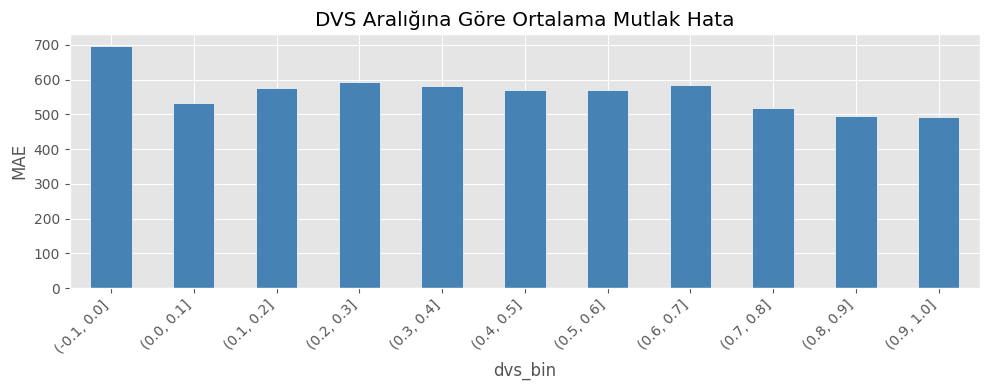

In [22]:
# Hata — DVS bazlı
test_df['dvs_bin'] = pd.cut(test_df['DVS'], bins=np.arange(-0.1, 1.1, 0.1)).astype(str)
dvs_err = test_df.groupby('dvs_bin')['abs_error'].mean().sort_index()

plt.figure(figsize=(10, 4))
dvs_err.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('DVS Aralığına Göre Ortalama Mutlak Hata')
plt.ylabel('MAE')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

---
## 9. Crop Bazlı Breakdown

In [23]:
crop_metrics = []
for crop, grp in test_df.groupby('crop_name'):
    if len(grp) < 5:
        continue
    crop_metrics.append({
        'crop':       crop,
        'n_rows':     len(grp),
        'RMSE':       round(mean_squared_error(grp[TARGET], grp['y_pred']) ** 0.5, 1),
        'MAE':        round(mean_absolute_error(grp[TARGET], grp['y_pred']), 1),
        'R2':         round(r2_score(grp[TARGET], grp['y_pred']), 3),
        'mean_verim': round(grp[TARGET].mean(), 1)
    })

crop_df = pd.DataFrame(crop_metrics).sort_values('R2', ascending=False)
print(crop_df.to_string(index=False))
print('\nEn kötü 5 ürün:')
print(crop_df.sort_values('R2', ascending=True).head(5).to_string(index=False))

       crop  n_rows   RMSE    MAE      R2  mean_verim
    cassava     967  558.1  357.5   0.923      1305.6
       rice     987  531.4  293.2   0.875       800.9
    sorghum     905  619.0  314.5   0.869      1190.2
     millet     854  318.7  209.8   0.868       685.5
sweetpotato     657  775.2  629.6   0.863      2117.3
  pigeonpea    1119  791.1  527.8   0.851      1924.5
      maize     841 1807.1 1117.1   0.825      1851.1
     cotton    1144  344.3  291.1   0.813       890.2
  sugarbeet     969 2023.5 1541.4   0.772      3765.4
     cowpea     735  495.0  248.3   0.740       571.5
    soybean     571  440.6  286.0   0.714       688.3
   mungbean     568  358.3  284.1   0.707       820.0
  groundnut     772  365.1  209.9   0.687       351.4
  sunflower    1038  616.2  402.0   0.639       527.2
     barley     946 1137.2  749.9   0.622      4322.4
 seed_onion     660 1739.0 1507.2   0.585      5007.4
     potato     982 1638.2 1374.9   0.345      3506.7
   chickpea    1098  580.5  

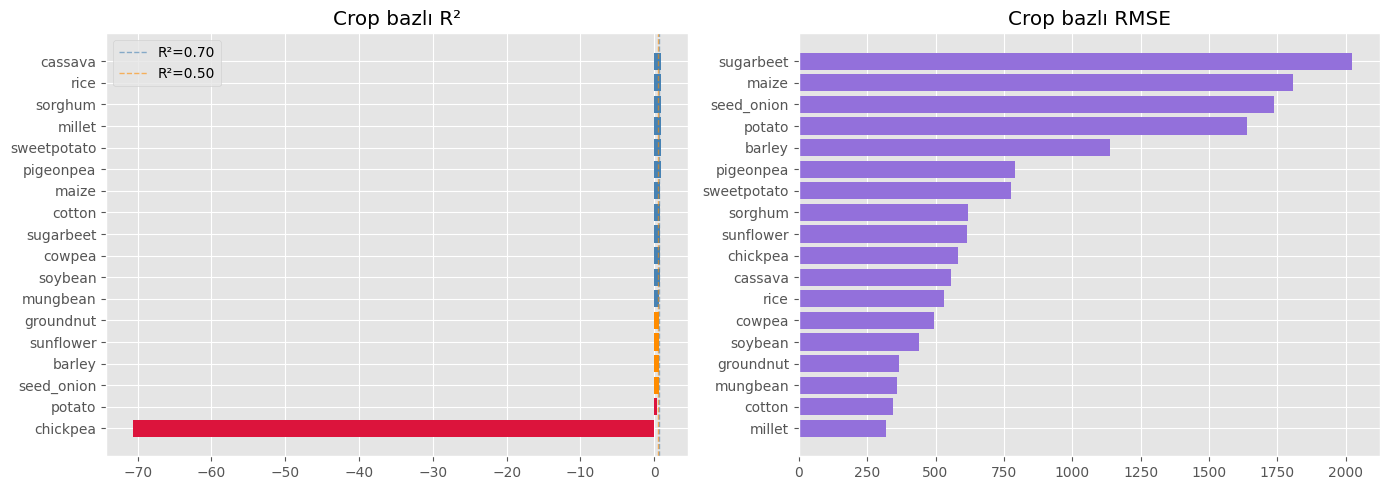

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

crop_s = crop_df.sort_values('R2', ascending=True)
colors = ['steelblue' if v >= 0.7 else 'darkorange' if v >= 0.5 else 'crimson' for v in crop_s['R2']]
axes[0].barh(crop_s['crop'], crop_s['R2'], color=colors)
axes[0].axvline(0.7, color='steelblue', ls='--', lw=1, alpha=0.6, label='R²=0.70')
axes[0].axvline(0.5, color='darkorange', ls='--', lw=1, alpha=0.6, label='R²=0.50')
axes[0].set_title('Crop bazlı R²')
axes[0].legend()

crop_r = crop_df.sort_values('RMSE', ascending=True)
axes[1].barh(crop_r['crop'], crop_r['RMSE'], color='mediumpurple')
axes[1].set_title('Crop bazlı RMSE')

plt.tight_layout()
plt.show()

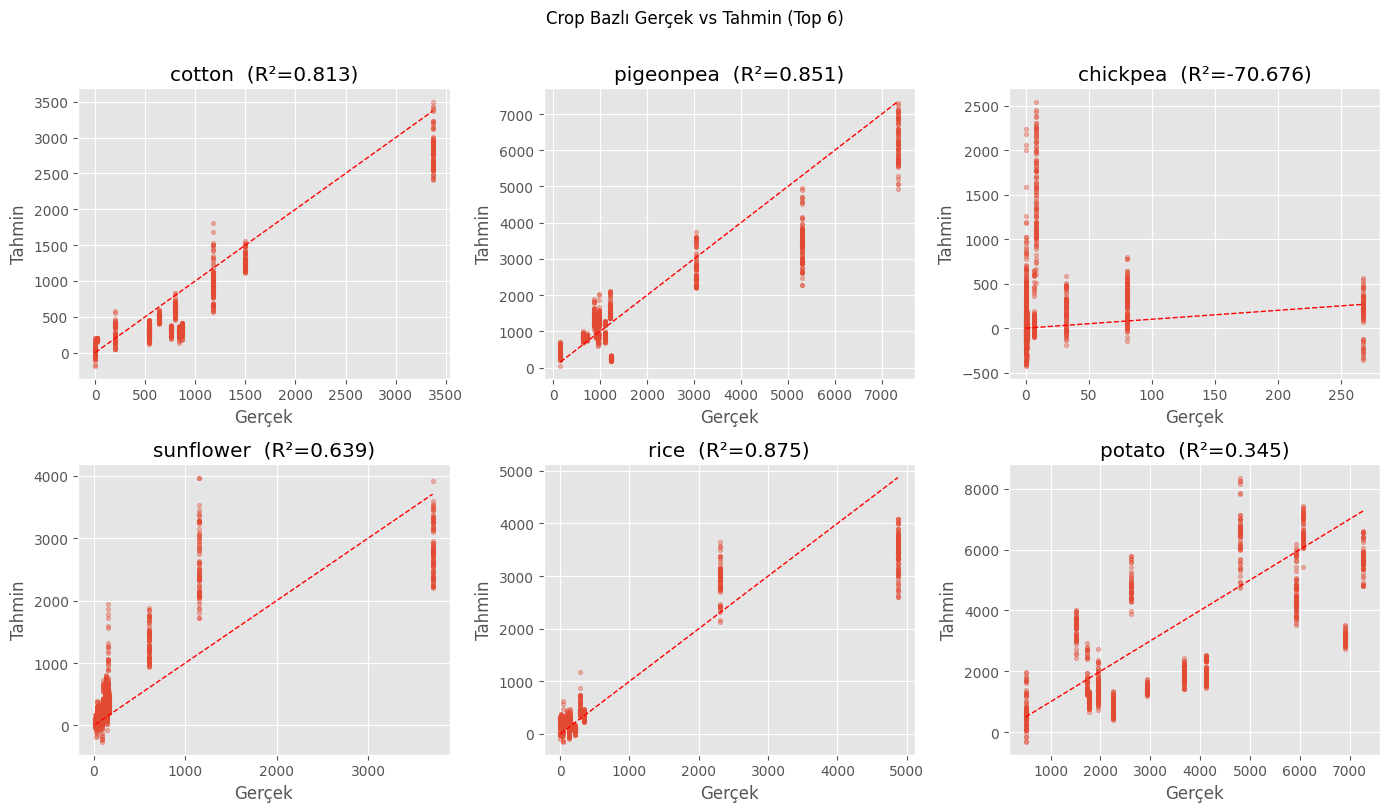

In [25]:
top_crops = crop_df.sort_values('n_rows', ascending=False)['crop'].head(6).tolist()
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for ax, crop in zip(axes.flat, top_crops):
    sub = test_df[test_df['crop_name'] == crop]
    ax.scatter(sub[TARGET], sub['y_pred'], alpha=0.4, s=10)
    lims = [sub[TARGET].min(), sub[TARGET].max()]
    ax.plot(lims, lims, 'r--', lw=1)
    ax.set_title(f'{crop}  (R²={r2_score(sub[TARGET], sub["y_pred"]):.3f})')
    ax.set_xlabel('Gerçek')
    ax.set_ylabel('Tahmin')

plt.suptitle('Crop Bazlı Gerçek vs Tahmin (Top 6)', y=1.01)
plt.tight_layout()
plt.show()

---
## 10. Model Kaydetme

In [26]:
model_path   = MODEL_DIR / 'lgbm_yield_final.pkl'
feature_path = MODEL_DIR / 'feature_cols.pkl'
metrics_path = MODEL_DIR / 'metrics.csv'

joblib.dump(final_model, model_path)
joblib.dump(FEATURE_COLS, feature_path)

metrics_df = pd.DataFrame([{
    'model':         'LightGBM',
    'strategy':      'GroupKFold (train only)',
    'dvs_filter':    'DVS < 1.0',
    'leaky_removed': str(LEAKY_COLS),
    'RMSE':          round(rmse, 2),
    'MAE':           round(mae, 2),
    'R2':            round(r2, 4),
    'MAPE':          round(mape, 2),
    'safe_MAPE':     round(safe_mape_val, 2),
    'n_features':    len(FEATURE_COLS),
    'n_estimators':   final_model.best_iteration_,
    'split_train':    len(train_df),  # GÜNCELLENDI
    'split_val':      len(val_df),    # GÜNCELLENDI
    'split_test':     len(test_df),   # GÜNCELLENDI
}])
metrics_df.to_csv(metrics_path, index=False)

print(f'Model      : {model_path}')
print(f'Features   : {feature_path}')
print(f'Metrikler  : {metrics_path}')
print('\n── Kaydedilen metrikler ──')
print(metrics_df.to_string(index=False))

Model      : /Users/sanlilarburak/Documents/Projects/pcse-ml/models/lgbm_yield_final.pkl
Features   : /Users/sanlilarburak/Documents/Projects/pcse-ml/models/feature_cols.pkl
Metrikler  : /Users/sanlilarburak/Documents/Projects/pcse-ml/models/metrics.csv

── Kaydedilen metrikler ──
   model                strategy dvs_filter                            leaky_removed    RMSE    MAE     R2     MAPE  safe_MAPE  n_features  n_estimators  split_train  split_val  split_test
LightGBM GroupKFold (train only)  DVS < 1.0 ['TWSO', 'TAGP', 'TWLV', 'TWST', 'TWRT'] 1007.28 592.19 0.8356 27108.46      61.21          36           274       135457      34403       15813


In [27]:
print('── Modeli yeniden yükle ve tahmin et ──')
loaded_model = joblib.load(model_path)
loaded_feats = joblib.load(feature_path)

sample = X_test.iloc[:5]
preds  = loaded_model.predict(sample)
print(pd.DataFrame({
    'Gerçek': y_test.values[:5],
    'Tahmin': preds.round(1),
    'Fark':   (y_test.values[:5] - preds).round(1)
}))

── Modeli yeniden yükle ve tahmin et ──
        Gerçek  Tahmin    Fark
0  4511.911288  3066.1  1445.8
1  4409.780370  2546.8  1862.9
2  5844.541680  4063.8  1780.7
3  4886.936438  7434.6 -2547.6
4  9326.438124  8161.4  1165.0
